<a href="https://colab.research.google.com/github/fatenahaq-blip/alpha-factor-research/blob/main/alpha_factor_research_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Momentum Alpha Factor Research

## Project objective

This project investigates whether shares with strong recent performance continue to outperform shares with weak recent performance.

The project will:

1. Download historical stock prices.
2. Calculate past six-month returns.
3. Rank stocks using a momentum factor.
4. Create high-momentum and low-momentum portfolios.
5. compare their future performance.
6. Evaluate whether the factor produced useful alpha.

## What is an alpha factor?

An alpha factor is a measurable signal used to rank investments.

Imagine that ten runners completed a race.

A momentum factor says:

> Look at which runners have recently been fastest. They may have a better chance of remaining fast in the next race.

In this project, the runners are stocks.

The momentum score is based on each stock's recent price performance.

In [1]:
!pip install -q yfinance

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

print("All tools are ready.")

All tools are ready.


In [3]:
tickers = [
    "AAPL", "MSFT", "AMZN", "GOOGL", "META",
    "NVDA", "JPM", "BAC", "WMT", "COST",
    "KO", "PEP", "XOM", "CVX", "JNJ",
    "PG", "HD", "DIS", "NFLX", "IBM"
]

print("Number of stocks:", len(tickers))
print(tickers)

Number of stocks: 20
['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'NVDA', 'JPM', 'BAC', 'WMT', 'COST', 'KO', 'PEP', 'XOM', 'CVX', 'JNJ', 'PG', 'HD', 'DIS', 'NFLX', 'IBM']


In [4]:
prices = yf.download(
    tickers=tickers,
    start="2018-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

print("Data downloaded.")
print("Table size:", prices.shape)

prices.head()

Data downloaded.
Table size: (2011, 20)


Ticker,AAPL,AMZN,BAC,COST,CVX,DIS,GOOGL,HD,IBM,JNJ,JPM,KO,META,MSFT,NFLX,NVDA,PEP,PG,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.267082,59.450500,24.510143,167.986923,88.640472,105.416779,53.188866,152.647934,102.657280,110.130829,85.516014,35.024223,179.840729,78.699898,20.107000,4.922530,90.649071,71.745132,28.800232,58.185482
2018-01-03,40.260063,60.209999,24.428175,170.002960,89.286636,105.869362,54.096317,153.443573,105.479111,111.182823,85.603149,34.947311,183.062439,79.066177,20.504999,5.246500,90.411057,71.658081,29.051456,59.328285
2018-01-04,40.447075,60.479500,24.747877,168.682709,89.008736,105.822220,54.306450,154.661301,107.615402,111.174911,86.829491,35.439522,182.725403,79.762054,20.563000,5.274155,90.856369,72.164597,29.077749,59.410381
2018-01-05,40.907578,61.457001,24.862631,167.478455,88.862816,105.247047,55.026566,156.276825,108.141151,112.092506,86.272079,35.431839,185.223465,80.750969,20.999001,5.318850,91.117439,72.212067,29.250107,59.362461
2018-01-08,40.755642,62.343498,24.690489,168.129639,89.300545,103.738411,55.220852,155.903366,108.793404,112.234863,86.399490,35.378010,186.640991,80.833359,21.205000,5.481824,90.595322,72.591988,29.682434,59.629330


In [5]:
missing_values = prices.isna().sum().sort_values(ascending=False)

missing_values

,0
Ticker,
AAPL,0
AMZN,0
BAC,0
COST,0
CVX,0
DIS,0
GOOGL,0
HD,0
IBM,0


In [6]:
prices = prices.dropna(axis=1, how="all")

print("Stocks remaining:", prices.shape[1])

Stocks remaining: 20


In [7]:
prices = prices.ffill()

In [8]:
monthly_prices = prices.resample("ME").last()

print("Monthly table size:", monthly_prices.shape)

monthly_prices.head()

Monthly table size: (96, 20)


Ticker,AAPL,AMZN,BAC,COST,CVX,DIS,GOOGL,HD,IBM,JNJ,JPM,KO,META,MSFT,NFLX,NVDA,PEP,PG,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2018-01-31,39.138023,72.544502,26.231594,173.829773,87.091125,102.465477,58.591454,163.096161,108.946495,109.308174,92.109001,36.600857,185.263077,86.995674,27.030001,6.069514,92.368988,68.854904,31.140137,59.738834
2018-02-28,41.806648,75.622498,26.313572,170.744110,78.534264,97.270096,54.710869,147.971817,104.729874,103.392845,91.973633,33.239941,176.767700,86.263596,29.138000,5.979394,84.253098,62.618599,26.293831,52.358387
2018-03-31,39.379749,72.366997,24.676176,168.534851,80.021873,94.705383,51.401215,145.525391,103.116875,102.015625,87.570045,33.696316,158.399002,83.963737,29.535000,5.722183,84.427162,63.224640,26.144981,51.577221
2018-04-30,38.788269,78.306503,24.618576,176.343140,87.789696,94.601662,50.481369,150.881302,97.424385,100.694176,87.061714,33.525608,170.502716,86.033592,31.246000,5.556884,78.076721,58.223953,25.995110,53.747875
2018-05-31,44.029514,81.481003,23.992130,177.826141,87.981888,93.790764,54.516594,153.162872,96.025581,95.931435,85.645103,33.362663,190.110535,91.321854,35.160000,6.235024,78.256203,58.891994,24.408257,56.729713


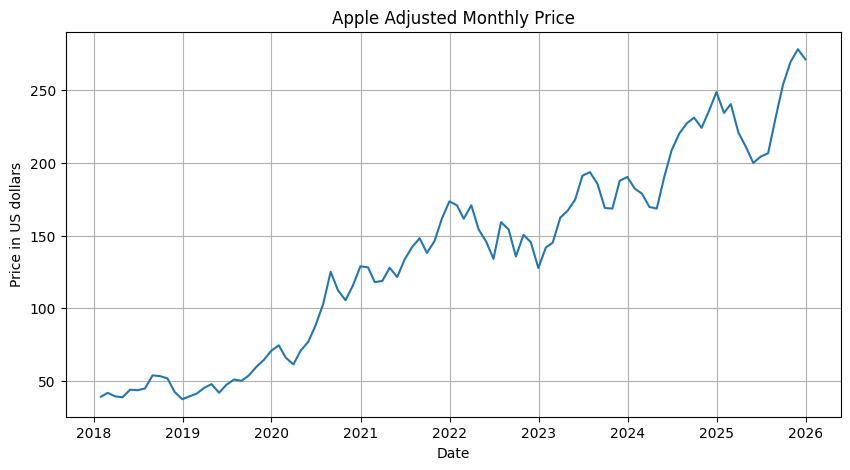

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(monthly_prices.index, monthly_prices["AAPL"])

plt.title("Apple Adjusted Monthly Price")
plt.xlabel("Date")
plt.ylabel("Price in US dollars")
plt.grid(True)
plt.show()

In [10]:
monthly_returns = monthly_prices.pct_change()

monthly_returns.head()

Ticker,AAPL,AMZN,BAC,COST,CVX,DIS,GOOGL,HD,IBM,JNJ,JPM,KO,META,MSFT,NFLX,NVDA,PEP,PG,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2018-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-28,0.068185,0.042429,0.003125,-0.017751,-0.098252,-0.050704,-0.066231,-0.092733,-0.038704,-0.054116,-0.001470,-0.091826,-0.045856,-0.008415,0.077987,-0.014848,-0.087864,-0.090572,-0.155629,-0.123545
2018-03-31,-0.058051,-0.043049,-0.062226,-0.012939,0.018942,-0.026367,-0.060494,-0.016533,-0.015402,-0.013320,-0.047879,0.013730,-0.103914,-0.026661,0.013625,-0.043016,0.002066,0.009678,-0.005661,-0.014920
2018-04-30,-0.015020,0.082075,-0.002334,0.046330,0.097071,-0.001095,-0.017895,0.036804,-0.055204,-0.012953,-0.005805,-0.005066,0.076413,0.024652,0.057931,-0.028887,-0.075218,-0.079094,-0.005732,0.042086
2018-05-31,0.135124,0.040539,-0.025446,0.008410,0.002189,-0.008572,0.079935,0.015122,-0.014358,-0.047299,-0.016271,-0.004860,0.115000,0.061467,0.125264,0.122036,0.002299,0.011474,-0.061044,0.055478


In [11]:
momentum_6m = monthly_prices.pct_change(periods=6)

momentum_6m.head(10)

Ticker,AAPL,AMZN,BAC,COST,CVX,DIS,GOOGL,HD,IBM,JNJ,JPM,KO,META,MSFT,NFLX,NVDA,PEP,PG,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2018-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-07-31,0.145569,0.225069,-0.027421,0.128622,0.026239,0.053399,0.038064,-0.005681,-0.096019,-0.027732,0.004243,-0.002719,-0.076569,0.126621,0.248428,-0.002589,-0.028135,-0.045990,-0.152651,-0.047215
2018-08-31,0.287386,0.330761,-0.028881,0.227816,0.077900,0.094614,0.115842,0.119692,-0.039298,0.051688,0.002484,0.049604,-0.014525,0.207753,0.261857,0.161187,0.037780,0.075871,0.084353,0.080247
2018-09-30,0.355377,0.383918,-0.008891,0.253249,0.091975,0.173636,0.163854,0.174694,0.007237,0.093424,0.036906,0.082149,0.029226,0.263370,0.266734,0.214852,0.042249,0.069154,0.068343,0.162948


In [12]:
Stock A six-month return = 25%
Stock B six-month return = 8%
Stock C six-month return = -10%

SyntaxError: invalid syntax (1007877884.py, line 1)

In [13]:
signal = momentum_6m.shift(1)

signal.head(10)

Ticker,AAPL,AMZN,BAC,COST,CVX,DIS,GOOGL,HD,IBM,JNJ,JPM,KO,META,MSFT,NFLX,NVDA,PEP,PG,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2018-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-31,0.145569,0.225069,-0.027421,0.128622,0.026239,0.053399,0.038064,-0.005681,-0.096019,-0.027732,0.004243,-0.002719,-0.076569,0.126621,0.248428,-0.002589,-0.028135,-0.045990,-0.152651,-0.047215
2018-09-30,0.287386,0.330761,-0.028881,0.227816,0.077900,0.094614,0.115842,0.119692,-0.039298,0.051688,0.002484,0.049604,-0.014525,0.207753,0.261857,0.161187,0.037780,0.075871,0.084353,0.080247


In [14]:
factor_rank = signal.rank(
    axis=1,
    method="average",
    pct=True
)

factor_rank.head(10)

Ticker,AAPL,AMZN,BAC,COST,CVX,DIS,GOOGL,HD,IBM,JNJ,JPM,KO,META,MSFT,NFLX,NVDA,PEP,PG,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2018-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-31,0.90,0.95,0.40,0.85,0.65,0.75,0.70,0.45,0.10,0.35,0.6,0.5,0.15,0.80,1.0,0.55,0.30,0.25,0.05,0.20
2018-09-30,0.95,1.00,0.10,0.85,0.45,0.60,0.65,0.70,0.05,0.35,0.2,0.3,0.15,0.80,0.9,0.75,0.25,0.40,0.55,0.50


In [17]:
example_date = factor_rank.dropna(how="all").index[-1]

example_ranking = pd.DataFrame({
    "Momentum": signal.loc[example_date],
    "Percentile Rank": factor_rank.loc[example_date]
}).sort_values("Percentile Rank", ascending=False)

print("Ranking date:", example_date.date())

example_ranking

Ranking date: 2025-12-31


,Momentum,Percentile Rank
Ticker,,
GOOGL,0.868256,1.00
AAPL,0.391273,0.95
JNJ,0.351474,0.90
NVDA,0.310014,0.85
BAC,0.229693,0.80
IBM,0.205818,0.75
JPM,0.197416,0.70
PEP,0.155139,0.65
XOM,0.153685,0.60


In [18]:
long_positions = factor_rank >= 0.80

long_positions.head()

Ticker,AAPL,AMZN,BAC,COST,CVX,DIS,GOOGL,HD,IBM,JNJ,JPM,KO,META,MSFT,NFLX,NVDA,PEP,PG,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2018-01-31,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2018-02-28,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2018-03-31,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2018-04-30,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2018-05-31,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [19]:
short_positions = factor_rank <= 0.20

short_positions.head()

Ticker,AAPL,AMZN,BAC,COST,CVX,DIS,GOOGL,HD,IBM,JNJ,JPM,KO,META,MSFT,NFLX,NVDA,PEP,PG,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2018-01-31,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2018-02-28,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2018-03-31,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2018-04-30,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2018-05-31,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [20]:
long_weights = long_positions.div(
    long_positions.sum(axis=1),
    axis=0
)

short_weights = short_positions.div(
    short_positions.sum(axis=1),
    axis=0
)

In [21]:
long_returns = (
    long_weights * monthly_returns
).sum(axis=1)

short_returns = (
    short_weights * monthly_returns
).sum(axis=1)

factor_returns = long_returns - short_returns

In [22]:
long_returns.name = "High Momentum"
short_returns.name = "Low Momentum"
factor_returns.name = "Momentum Factor"

In [23]:
performance = pd.concat(
    [long_returns, short_returns, factor_returns],
    axis=1
).dropna()

performance.head()

,High Momentum,Low Momentum,Momentum Factor
Date,,,
2018-01-31,0.0,0.0,0.0
2018-02-28,0.0,0.0,0.0
2018-03-31,0.0,0.0,0.0
2018-04-30,0.0,0.0,0.0
2018-05-31,0.0,0.0,0.0


In [24]:
benchmark_prices = yf.download(
    "^GSPC",
    start="2018-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

benchmark_monthly = benchmark_prices.resample("ME").last()
benchmark_returns = benchmark_monthly.pct_change()

In [25]:
if isinstance(benchmark_returns, pd.DataFrame):
    benchmark_returns = benchmark_returns.iloc[:, 0]

benchmark_returns.name = "S&P 500"

In [26]:
performance = performance.join(
    benchmark_returns,
    how="inner"
)

performance.head()

,High Momentum,Low Momentum,Momentum Factor,S&P 500
Date,,,,
2018-01-31,0.0,0.0,0.0,NaN
2018-02-28,0.0,0.0,0.0,-0.038947
2018-03-31,0.0,0.0,0.0,-0.026884
2018-04-30,0.0,0.0,0.0,0.002719
2018-05-31,0.0,0.0,0.0,0.021608


In [27]:
cumulative_performance = (
    1 + performance
).cumprod()

cumulative_performance.head()

,High Momentum,Low Momentum,Momentum Factor,S&P 500
Date,,,,
2018-01-31,1.0,1.0,1.0,NaN
2018-02-28,1.0,1.0,1.0,0.961053
2018-03-31,1.0,1.0,1.0,0.935215
2018-04-30,1.0,1.0,1.0,0.937758
2018-05-31,1.0,1.0,1.0,0.958021


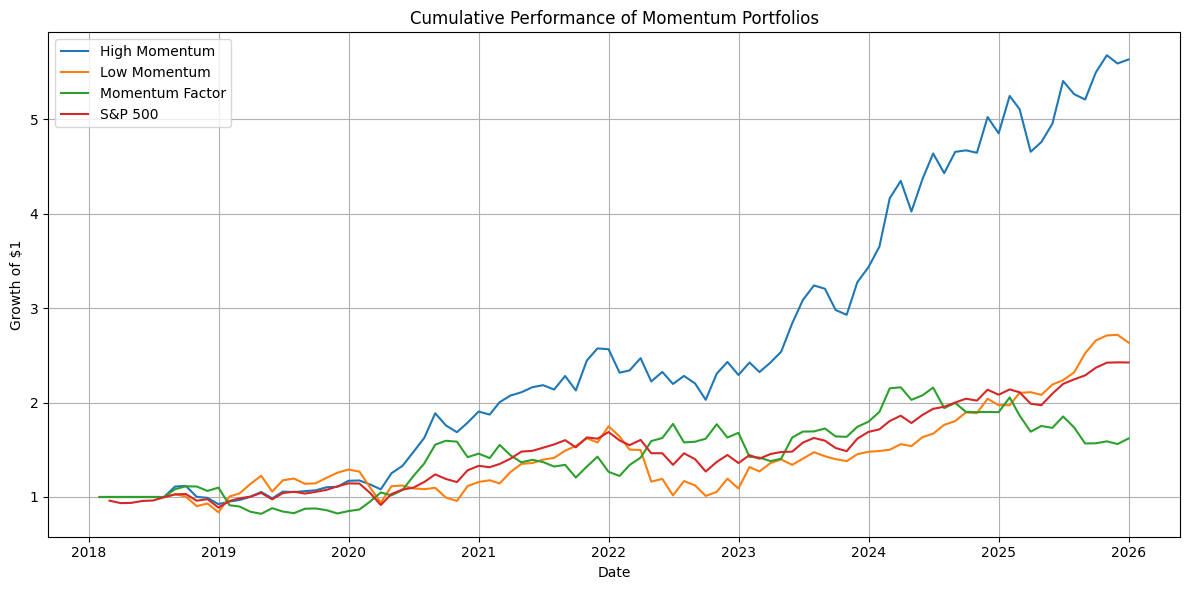

In [28]:
plt.figure(figsize=(12, 6))

for column in cumulative_performance.columns:
    plt.plot(
        cumulative_performance.index,
        cumulative_performance[column],
        label=column
    )

plt.title("Cumulative Performance of Momentum Portfolios")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
def calculate_statistics(return_series, periods_per_year=12):
    return_series = return_series.dropna()

    annual_return = (
        (1 + return_series).prod()
        ** (periods_per_year / len(return_series))
        - 1
    )

    annual_volatility = (
        return_series.std() * np.sqrt(periods_per_year)
    )

    sharpe_ratio = (
        annual_return / annual_volatility
        if annual_volatility != 0
        else np.nan
    )

    cumulative = (1 + return_series).cumprod()
    running_peak = cumulative.cummax()
    drawdown = cumulative / running_peak - 1
    maximum_drawdown = drawdown.min()

    positive_months = (return_series > 0).mean()

    return pd.Series({
        "Annual Return": annual_return,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": maximum_drawdown,
        "Positive Months": positive_months
    })

In [30]:
statistics = performance.apply(calculate_statistics).T

statistics

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown,Positive Months
High Momentum,0.241181,0.209265,1.152517,-0.211579,0.593750
Low Momentum,0.128767,0.251373,0.512255,-0.421749,0.583333
Momentum Factor,0.062126,0.227610,0.272950,-0.277948,0.520833
S&P 500,0.118349,0.164834,0.717985,-0.247695,0.663158


In [31]:
display_statistics = statistics.copy()

percentage_columns = [
    "Annual Return",
    "Annual Volatility",
    "Maximum Drawdown",
    "Positive Months"
]

display_statistics[percentage_columns] = (
    display_statistics[percentage_columns] * 100
)

display_statistics = display_statistics.round(2)

display_statistics

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown,Positive Months
High Momentum,24.12,20.93,1.15,-21.16,59.38
Low Momentum,12.88,25.14,0.51,-42.17,58.33
Momentum Factor,6.21,22.76,0.27,-27.79,52.08
S&P 500,11.83,16.48,0.72,-24.77,66.32


In [32]:
forward_returns = monthly_returns

In [33]:
ic_values = []

for date in signal.index:
    if date not in forward_returns.index:
        continue

    month_data = pd.concat(
        [
            signal.loc[date].rename("Factor"),
            forward_returns.loc[date].rename("Forward Return")
        ],
        axis=1
    ).dropna()

    if len(month_data) >= 5:
        ic = month_data.corr(
            method="spearman"
        ).iloc[0, 1]

        ic_values.append({
            "Date": date,
            "IC": ic
        })

ic_series = (
    pd.DataFrame(ic_values)
    .set_index("Date")["IC"]
)

ic_series.head()

,IC
Date,
2018-08-31,0.311278
2018-09-30,0.019549
2018-10-31,-0.267669
2018-11-30,-0.090226
2018-12-31,0.261654


In [34]:
print("Average IC:", round(ic_series.mean(), 4))
print("IC volatility:", round(ic_series.std(), 4))
print("Positive IC months:", round((ic_series > 0).mean() * 100, 2), "%")

Average IC: 0.0316
IC volatility: 0.3499
Positive IC months: 55.06 %


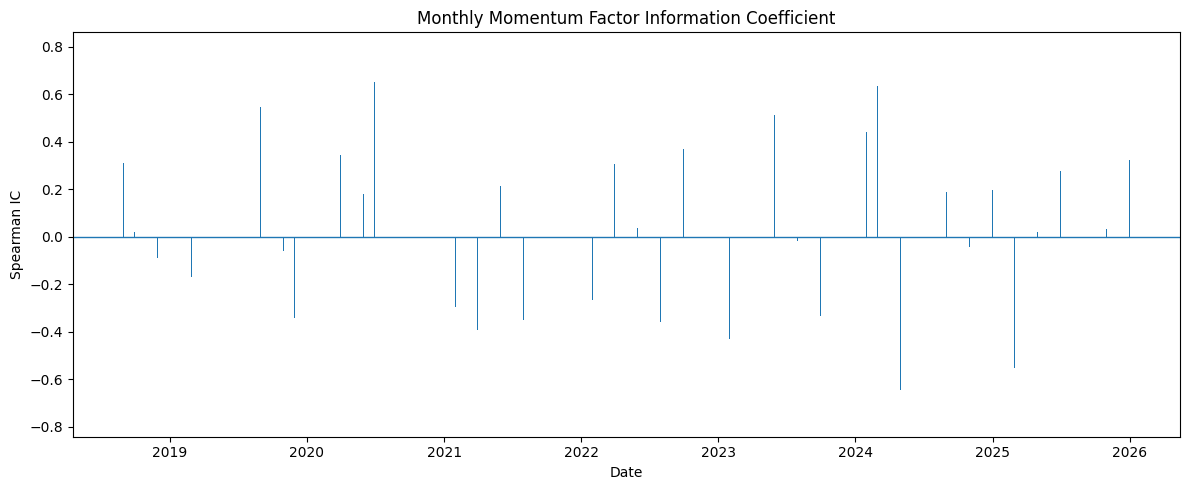

In [35]:
plt.figure(figsize=(12, 5))

plt.bar(ic_series.index, ic_series.values)
plt.axhline(0, linewidth=1)

plt.title("Monthly Momentum Factor Information Coefficient")
plt.xlabel("Date")
plt.ylabel("Spearman IC")
plt.tight_layout()
plt.show()

In [36]:
long_turnover = (
    long_weights.diff().abs().sum(axis=1) / 2
)

short_turnover = (
    short_weights.diff().abs().sum(axis=1) / 2
)

average_long_turnover = long_turnover.mean()
average_short_turnover = short_turnover.mean()

print("Average long turnover:", round(average_long_turnover, 4))
print("Average short turnover:", round(average_short_turnover, 4))

Average long turnover: 0.2688
Average short turnover: 0.2995


In [37]:
transaction_cost_rate = 0.001

net_long_returns = (
    long_returns
    - long_turnover * transaction_cost_rate
)

net_short_returns = (
    short_returns
    - short_turnover * transaction_cost_rate
)

net_factor_returns = (
    net_long_returns - net_short_returns
)

net_factor_returns.name = "Net Momentum Factor"

In [38]:
cost_comparison = pd.concat(
    [
        factor_returns.rename("Gross Momentum Factor"),
        net_factor_returns
    ],
    axis=1
).dropna()

cost_comparison_statistics = (
    cost_comparison
    .apply(calculate_statistics)
    .T
)

cost_comparison_statistics

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown,Positive Months
Gross Momentum Factor,0.062126,0.227610,0.272950,-0.277948,0.520833
Net Momentum Factor,0.062524,0.227572,0.274746,-0.276816,0.520833


In [39]:
lookback_periods = [3, 6, 9, 12]

robustness_results = []

for lookback in lookback_periods:
    test_signal = (
        monthly_prices
        .pct_change(periods=lookback)
        .shift(1)
    )

    test_rank = test_signal.rank(
        axis=1,
        pct=True
    )

    test_long = test_rank >= 0.80
    test_short = test_rank <= 0.20

    test_long_weights = test_long.div(
        test_long.sum(axis=1),
        axis=0
    )

    test_short_weights = test_short.div(
        test_short.sum(axis=1),
        axis=0
    )

    test_factor_returns = (
        (test_long_weights * monthly_returns).sum(axis=1)
        -
        (test_short_weights * monthly_returns).sum(axis=1)
    )

    test_stats = calculate_statistics(
        test_factor_returns
    )

    robustness_results.append({
        "Lookback Months": lookback,
        "Annual Return": test_stats["Annual Return"],
        "Annual Volatility": test_stats["Annual Volatility"],
        "Sharpe Ratio": test_stats["Sharpe Ratio"],
        "Maximum Drawdown": test_stats["Maximum Drawdown"]
    })

robustness_table = pd.DataFrame(robustness_results)

robustness_table

,Lookback Months,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
0,3,0.074087,0.249422,0.297034,-0.386704
1,6,0.062126,0.227610,0.272950,-0.277948
2,9,0.053199,0.231927,0.229379,-0.358867
3,12,0.093817,0.231271,0.405657,-0.374095


## Conclusion

This project tested a cross-sectional momentum alpha factor using a sample of large US stocks.

Stocks were ranked each month according to their previous six-month price performance. The highest-ranked 20% formed the high-momentum portfolio, while the lowest-ranked 20% formed the low-momentum portfolio.

### Main observations

- The high-momentum portfolio produced an annualized return of **[insert result]%**.
- The low-momentum portfolio produced an annualized return of **[insert result]%**.
- The long-short momentum factor produced a Sharpe ratio of **[insert result]**.
- The average monthly information coefficient was **[insert result]**.
- After assumed transaction costs, the factor return changed from **[insert result]%** to **[insert result]%**.

### Interpretation

The evidence **[supported / did not consistently support]** the idea that recent winners continued to outperform recent losers in this sample.

### Limitations

1. The stock universe was small.
2. The universe used currently recognisable companies and may contain survivorship bias.
3. The data source was suitable for educational research but not institutional production.
4. Taxes, borrowing costs, bid-ask spreads and market impact were not fully modelled.
5. The study did not control for market, size, value, sector or other risk exposures.
6. Historical performance does not guarantee future performance.